### Name: Nihar Harde
### C1-03
### NLP Lab - 08

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
data = pd.read_csv('IMDB Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = nltk.WordNetLemmatizer()
def preprocess(text):
  text = text.lower()
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word.isalpha()]
  tokens = [word for word in tokens if word not in stop_words]
  tokens = [lemmatizer.lemmatize(word) for word in tokens]
  return " ".join(tokens)
data['Cleaned Text'] = data['review'].apply(preprocess)
data.head()

,review,sentiment,Cleaned Text
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [4]:
data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})
y = data['sentiment']

In [30]:
vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df = 2,
    max_df = 0.95
)
X = vectorizer.fit_transform(data['Cleaned Text'])
y = data['sentiment']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [32]:
models = {
    'Naive Bayes' : MultinomialNB(),
    'Logistic Regression' : LogisticRegression(max_iter = 200),
    'SVM' : LinearSVC(),
    'Random Forest' : RandomForestClassifier(),
    'Gradient Boosting' : GradientBoostingClassifier(),
    'XGBoost' : XGBClassifier()
}

In [33]:
print(data['sentiment'].unique())
print(data['sentiment'].value_counts())


print("NaN count:", data['sentiment'].isna().sum())


data = data.dropna(subset=['sentiment'])
data['sentiment'] = data['sentiment'].astype(int)


X = vectorizer.fit_transform(data['Cleaned Text'])
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("y unique values:", y.unique())
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

[1 0]
sentiment
1    25000
0    25000
Name: count, dtype: int64
NaN count: 0
y unique values: [1 0]
Train size: (40000, 100000)
Test size: (10000, 100000)


In [35]:
results = []
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, pos_label = 1)
  recall = recall_score(y_test, y_pred, pos_label = 1)
  f1 = f1_score(y_test, y_pred, pos_label = 1)
  results.append([name, accuracy, precision, recall, f1])
results

[['Naive Bayes',
  0.8874,
  0.8822035553819105,
  0.8962095653899583,
  0.8891514077574325],
 ['Logistic Regression',
  0.9,
  0.8914518317503393,
  0.9126810875173645,
  0.9019415571680721],
 ['SVM', 0.9066, 0.9023720839051167, 0.9134748958126613, 0.9078895463510848],
 ['Random Forest',
  0.8628,
  0.8635732698790403,
  0.8642587815042667,
  0.8639158897044237],
 ['Gradient Boosting',
  0.8124,
  0.7868674043170687,
  0.8608850962492558,
  0.8222137983320698],
 ['XGBoost',
  0.8574,
  0.8484088717454195,
  0.8729906727525303,
  0.8605242566510172]]

In [36]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8874,0.882204,0.896210,0.889151
1,Logistic Regression,0.9000,0.891452,0.912681,0.901942
2,SVM,0.9066,0.902372,0.913475,0.907890
3,Random Forest,0.8628,0.863573,0.864259,0.863916
4,Gradient Boosting,0.8124,0.786867,0.860885,0.822214
5,XGBoost,0.8574,0.848409,0.872991,0.860524


Best Model: SVM | Accuracy: 90.66%


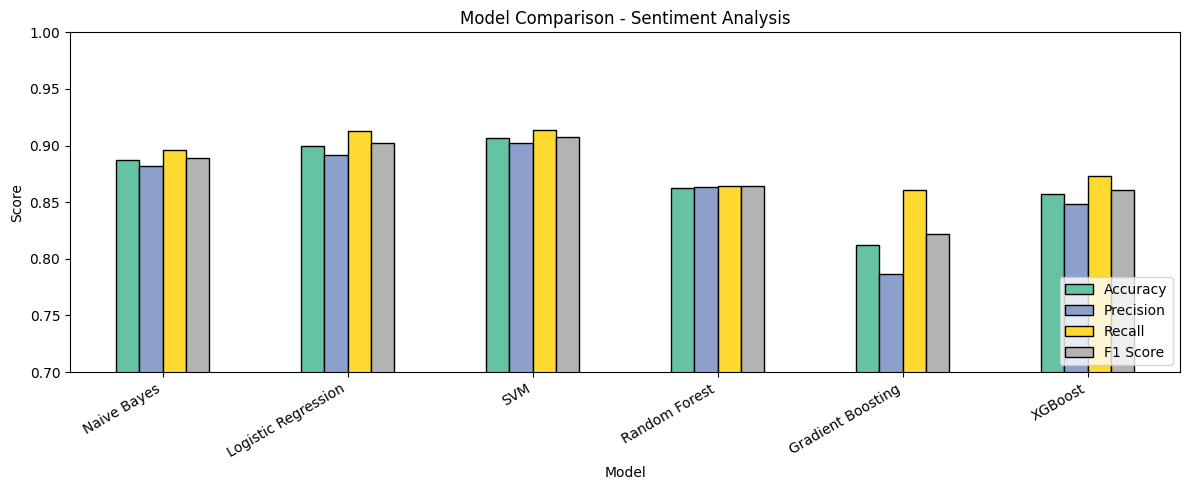

In [37]:
import matplotlib.pyplot as plt

# Finding best model
best_idx = results_df['Accuracy'].idxmax()
best_name = results_df.loc[best_idx, 'Model']
best_model = models[best_name]
print(f"Best Model: {best_name} | Accuracy: {results_df.loc[best_idx, 'Accuracy']*100:.2f}%")

# Bar chart comparison
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black'
)
plt.title('Model Comparison - Sentiment Analysis')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

# Retrain best model (SVM) on data
best_model_final = LinearSVC()
best_model_final.fit(X_train, y_train)
y_pred = best_model_final.predict(X_test)

print("\nOPTIMIZED MODEL PERFORMANCE (SVM):\n")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))


OPTIMIZED MODEL PERFORMANCE (SVM):

Accuracy : 0.9066
Precision: 0.9024
Recall   : 0.9135
F1 Score : 0.9079



Confusion Matrix:



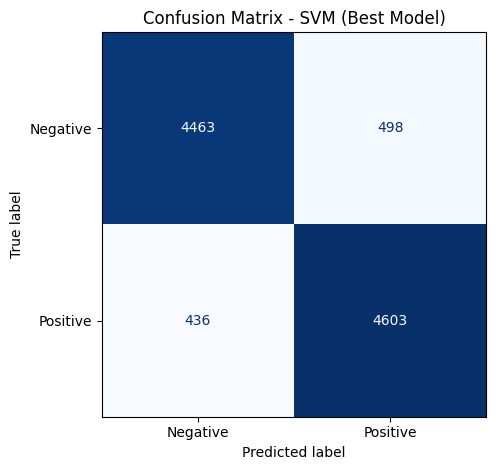

In [41]:
print("\nConfusion Matrix:\n")
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Negative', 'Positive'],
    colorbar=False,
    cmap='Blues'
)
plt.title("Confusion Matrix - SVM (Best Model)")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [43]:

text = ["This movie was fantastic but uninspiring"]
clean = preprocess(text[0])
vector = vectorizer.transform([clean])
prediction = best_model_final.predict(vector)
print("Predicted Sentiment : ", prediction[0])

Predicted Sentiment :  1


In [42]:
import pickle

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model_final, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model saved as: sentiment_model.pkl")
print("Vectorizer saved as: vectorizer.pkl")

Model saved as: sentiment_model.pkl
Vectorizer saved as: vectorizer.pkl


In [48]:
!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

import subprocess
import time
import re

app_code = """
import streamlit as st
import pickle
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

with open('sentiment_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

st.set_page_config(page_title='Movie Review Sentiment Analyzer', page_icon='🎬')
st.title('🎬 Movie Review Sentiment Analyzer')
st.markdown('Enter a movie review below and the model will predict whether it is **Positive** or **Negative**.')

review = st.text_area('✍️ Enter Movie Review Here:', height=200, placeholder='e.g. The movie was absolutely fantastic!')

if st.button('Analyze Sentiment'):
    if review.strip() == '':
        st.warning('Please enter a review before clicking Analyze.')
    else:
        cleaned = preprocess(review)
        vectorized = vectorizer.transform([cleaned])
        prediction = model.predict(vectorized)[0]

        st.markdown('---')
        if prediction == 1:
            st.success('✅ Sentiment: POSITIVE')
            st.balloons()
        else:
            st.error('❌ Sentiment: NEGATIVE')

        st.markdown('---')
        st.markdown(f'**Cleaned Input:** {cleaned}')
"""

# Write app.py
with open('app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py written successfully!")

# Start Streamlit
streamlit_process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
print("✅ Streamlit started, waiting...")
time.sleep(8)

# Start Cloudflare tunnel
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
print("✅ Cloudflare tunnel started, fetching URL...")
time.sleep(5)

# Extract public URL
url_found = False
for _ in range(30):
    line = tunnel.stderr.readline().decode()
    match = re.search(r'https://[\w\-]+\.trycloudflare\.com', line)
    if match:
        print("\n🌐 Streamlit app running at:", match.group())
        url_found = True
        break
    time.sleep(1)

if not url_found:
    print("❌ URL not found. Try running the tunnel cell again after 10 seconds.")

cloudflared: Text file busy
✅ app.py written successfully!
✅ Streamlit started, waiting...
✅ Cloudflare tunnel started, fetching URL...

🌐 Streamlit app running at: https://titled-elephant-manually-sitemap.trycloudflare.com
